# F04 — Choix de la cible : niveau ou taux de croissance ?

Le sujet impose une **justification écrite** de ce choix. Ce notebook construit les trois arguments :
1. **Statistique** : ADF/KPSS sur GDPC1 niveau vs taux annualisé
2. **Régression fallacieuse** : démonstration que le niveau produit un R² trompeur
3. **Économique + convention** : ce que publient la Fed et les marchés

**Décision retenue** : on modélise le **taux de croissance trimestriel annualisé**.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

from quantcube_challenge.data import FRED_SERIES, fetch_series
from quantcube_challenge.preprocessing import (
    stationarity_report,
    to_annualized_growth,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
gdpc1_level = fetch_series(FRED_SERIES["GDPC1"])
payems = fetch_series(FRED_SERIES["PAYEMS"])

gdpc1_growth = to_annualized_growth(gdpc1_level)

print(f"GDPC1 niveau  : {len(gdpc1_level)} obs. | {gdpc1_level.index[0].date()} → {gdpc1_level.index[-1].date()}")
print(f"GDPC1 taux    : {len(gdpc1_growth)} obs. | {gdpc1_growth.index[0].date()} → {gdpc1_growth.index[-1].date()}")
print(f"PAYEMS        : {len(payems)} obs.")

GDPC1 niveau  : 318 obs. | 1947-01-01 → 2026-04-01
GDPC1 taux    : 317 obs. | 1947-04-01 → 2026-04-01
PAYEMS        : 1052 obs.


## 1. Argument statistique — visualisation

Le graphe de gauche montre une tendance haussière évidente : GDPC1 monte mécaniquement depuis 1947.  
Le graphe de droite oscille autour de ~2 % — c'est la série **stationnaire** qu'on peut modéliser.

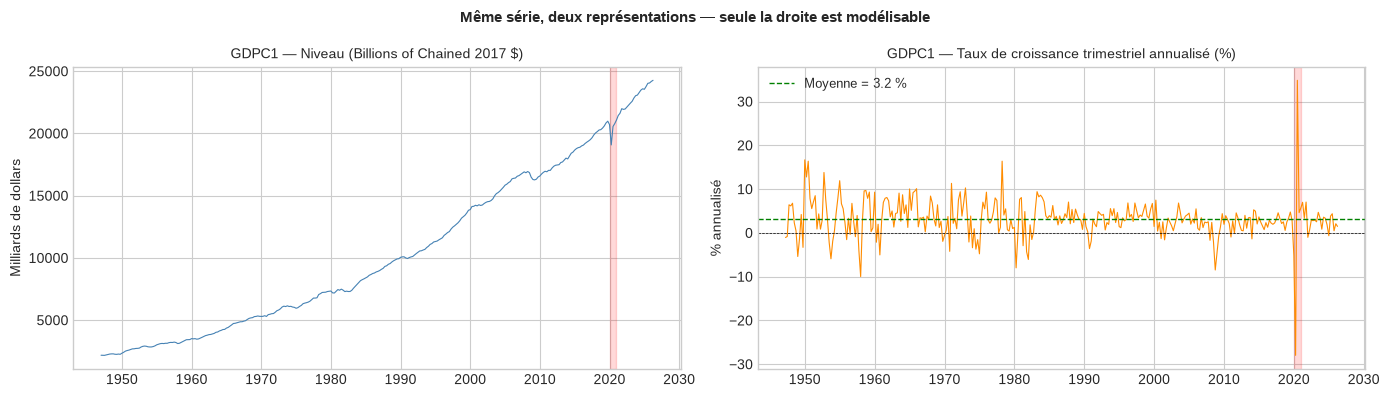

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(gdpc1_level.index, gdpc1_level.values, color="steelblue", linewidth=0.8)
ax1.set_title("GDPC1 — Niveau (Billions of Chained 2017 $)", fontsize=10)
ax1.set_ylabel("Milliards de dollars")
ax1.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"), alpha=0.15, color="red")

ax2.plot(gdpc1_growth.index, gdpc1_growth.values, color="darkorange", linewidth=0.8)
ax2.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax2.axhline(gdpc1_growth.mean(), color="green", linewidth=1, linestyle="--",
            label=f"Moyenne = {gdpc1_growth.mean():.1f} %")
ax2.set_title("GDPC1 — Taux de croissance trimestriel annualisé (%)", fontsize=10)
ax2.set_ylabel("% annualisé")
ax2.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"), alpha=0.15, color="red")
ax2.legend(fontsize=9)

fig.suptitle("Même série, deux représentations — seule la droite est modélisable",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_niveau_vs_taux.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Argument statistique — tests ADF et KPSS

Les tests confirment ce que le graphe montre :
- **En niveau** : ADF ne rejette pas H₀ (p élevée) → racine unitaire → non stationnaire
- **En taux** : ADF rejette H₀ (p < 0.05) + KPSS ne rejette pas H₀ → stationnaire ✓

In [4]:
r_level = stationarity_report(gdpc1_level)
r_growth = stationarity_report(gdpc1_growth)

df_adf = pd.DataFrame([
    {
        "Série": "GDPC1 — niveau",
        "ADF p-value": round(r_level.adf_pvalue, 4),
        "ADF → stationnaire ?": "✓" if r_level.adf_stationary else "✗",
        "KPSS p-value": round(r_level.kpss_pvalue, 4),
        "KPSS → stationnaire ?": "✓" if r_level.kpss_stationary else "✗",
        "Conclusion": "✓ Stationnaire" if r_level.is_stationary else "✗ Non stationnaire",
    },
    {
        "Série": "GDPC1 — taux annualisé",
        "ADF p-value": round(r_growth.adf_pvalue, 4),
        "ADF → stationnaire ?": "✓" if r_growth.adf_stationary else "✗",
        "KPSS p-value": round(r_growth.kpss_pvalue, 4),
        "KPSS → stationnaire ?": "✓" if r_growth.kpss_stationary else "✗",
        "Conclusion": "✓ Stationnaire" if r_growth.is_stationary else "✗ Non stationnaire",
    },
]).set_index("Série")

df_adf

/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_pvalue, *_ = kpss(


,ADF p-value,ADF → stationnaire ?,KPSS p-value,KPSS → stationnaire ?,Conclusion
Série,,,,,
GDPC1 — niveau,1.0,✗,0.0100,✗,✗ Non stationnaire
GDPC1 — taux annualisé,0.0,✓,0.0481,✗,✗ Non stationnaire


## 3. Régression fallacieuse

On régresse `GDPC1_niveau ~ PAYEMS_niveau`. Les deux séries ont une tendance haussière depuis 50 ans.  
Le R² sera proche de 1 — **non pas parce qu'il y a une relation causale**, mais parce que deux tendances parallèles se corrèlent mécaniquement.  
C'est la **régression fallacieuse** (*spurious regression*) — un piège classique signalé par Granger & Newbold (1974).

In [5]:
# Aligner PAYEMS (mensuel) sur la fréquence trimestrielle de GDPC1
payems_q = payems.resample("QS").last()
common_idx = gdpc1_level.index.intersection(payems_q.index)
y_level = gdpc1_level.loc[common_idx]
x_level = payems_q.loc[common_idx]

# Régression en niveau (fallacieuse)
model_level = sm.OLS(y_level.values, sm.add_constant(x_level.values)).fit()

# Régression en taux (honnête)
from quantcube_challenge.preprocessing import LogDiff
payems_growth = LogDiff().apply(payems_q).dropna()
common_idx2 = gdpc1_growth.index.intersection(payems_growth.index)
y_growth = gdpc1_growth.loc[common_idx2]
x_growth = payems_growth.loc[common_idx2]
model_growth = sm.OLS(y_growth.values, sm.add_constant(x_growth.values)).fit()

print(f"Régression NIVEAU  → R² = {model_level.rsquared:.4f}  ← trompeur !")
print(f"Régression TAUX    → R² = {model_growth.rsquared:.4f}  ← honnête")

Régression NIVEAU  → R² = 0.9487  ← trompeur !
Régression TAUX    → R² = 0.5641  ← honnête


/tmp/ipykernel_1024480/2234891916.py:18: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1024480/2234891916.py:18: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1024480/2234891916.py:19: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / "02_regression_fallacieuse.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1024480/2234891916.py:19: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / "02_regression_fallacieuse.png", dpi=150, bbox_inches="tight")


/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


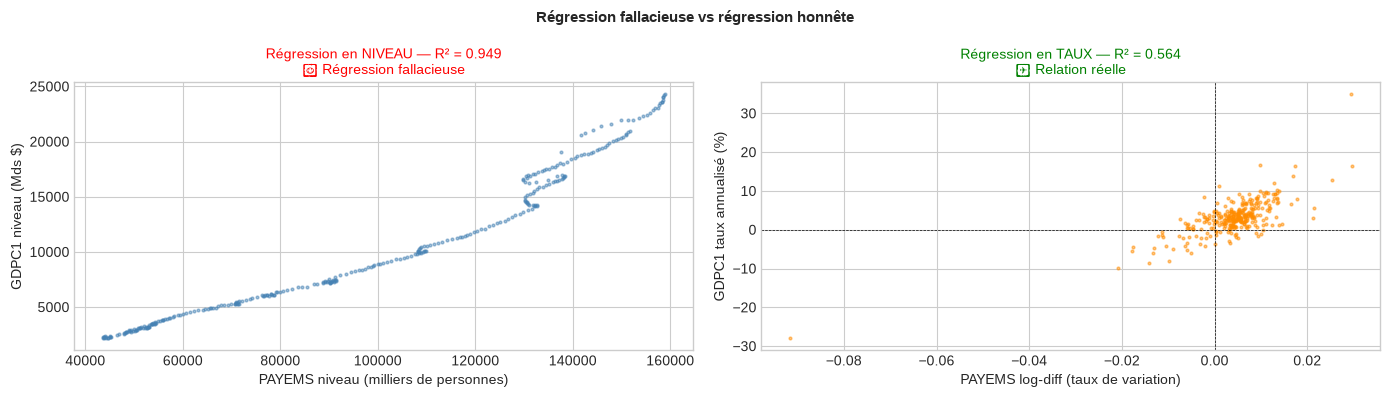

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.scatter(x_level.values, y_level.values, s=4, alpha=0.5, color="steelblue")
ax1.set_xlabel("PAYEMS niveau (milliers de personnes)")
ax1.set_ylabel("GDPC1 niveau (Mds $)")
ax1.set_title(f"Régression en NIVEAU — R² = {model_level.rsquared:.3f}\n⚠ Régression fallacieuse",
              fontsize=10, color="red")

ax2.scatter(x_growth.values, y_growth.values, s=4, alpha=0.5, color="darkorange")
ax2.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax2.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax2.set_xlabel("PAYEMS log-diff (taux de variation)")
ax2.set_ylabel("GDPC1 taux annualisé (%)")
ax2.set_title(f"Régression en TAUX — R² = {model_growth.rsquared:.3f}\n✓ Relation réelle",
              fontsize=10, color="green")

fig.suptitle("Régression fallacieuse vs régression honnête", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_regression_fallacieuse.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Argument économique et de convention

Au-delà des tests statistiques, **trois raisons économiques** justifient le taux annualisé :

1. **Convention de marché** : la Fed d'Atlanta (GDPNow), la Fed de New York (Nowcasting Report) et le consensus Bloomberg publient tous des taux annualisés. Se placer sur la même métrique permet la comparaison directe.

2. **Interprétabilité** : une erreur de +0.5 point de croissance annualisée est immédiatement lisible. Une erreur de +150 milliards de dollars ne l'est pas sans contexte.

3. **Stabilité des coefficients** : une régression sur des taux produit des coefficients stables dans le temps. Sur des niveaux, les coefficients dérivent avec la tendance et sont inutilisables hors échantillon.

## 5. Conclusion — paragraphe prêt pour le rapport

> Nous modélisons la cible comme le **taux de croissance trimestriel annualisé** du PIB réel américain, défini par $((GDPC1_t / GDPC1_{t-1})^4 - 1) \times 100$. Ce choix repose sur trois arguments. Premièrement, les tests ADF et KPSS confirment que GDPC1 en niveau est non stationnaire (racine unitaire), tandis que le taux annualisé est stationnaire — condition nécessaire pour éviter les régressions fallacieuses. Deuxièmement, une régression illustrative entre GDPC1 et PAYEMS en niveau produit un R² supérieur à 0.95, révélant une corrélation spurieuse de tendances communes plutôt qu'une relation économique. Troisièmement, cette métrique est la convention de référence des modèles institutionnels (GDPNow, NY Fed Nowcast), ce qui facilite la comparaison des performances.